# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [22]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset

# Nuestros paquetes
import sweetviz as swv
import numpy as np

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [23]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="data")
df = ds.to_pandas()

## Lectura de Datos

In [24]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,NaN,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,NaN,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,NaN,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,NaN,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,NaN,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,NaN,Vox


In [25]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   idx          30213 non-null  int64
 1   article_idx  30213 non-null  int64
 2   date         30213 non-null  str  
 3   year         30213 non-null  str  
 4   month        30213 non-null  str  
 5   day          30213 non-null  str  
 6   author       18808 non-null  str  
 7   title        30213 non-null  str  
 8   article      29037 non-null  str  
 9   url          30072 non-null  str  
 10  section      19981 non-null  str  
 11  publication  30072 non-null  str  
dtypes: int64(2), str(10)
memory usage: 96.1 MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [26]:
# Analice datos faltantes por columna
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Filas faltantes': missing, 'Porcentaje de filas vacias (%)': missing_pct})
missing_df_filtered = missing_df[missing_df['Filas faltantes'] > 0].sort_values('Porcentaje de filas vacias (%)', ascending=False)

print(f"Total de filas: {len(df)}")
print(f"Total de columnas: {len(df.columns)}\n")

if not missing_df_filtered.empty:
    print("Columnas con datos faltantes:")
    display(missing_df_filtered)
else:
    print("No hay datos faltantes en ninguna columna.")

Total de filas: 30213
Total de columnas: 12

Columnas con datos faltantes:


,Filas faltantes,Porcentaje de filas vacias (%)
author,11405,37.75
section,10232,33.87
article,1176,3.89
url,141,0.47
publication,141,0.47


                                             |          | [  0%]   00:00 -> (? left)


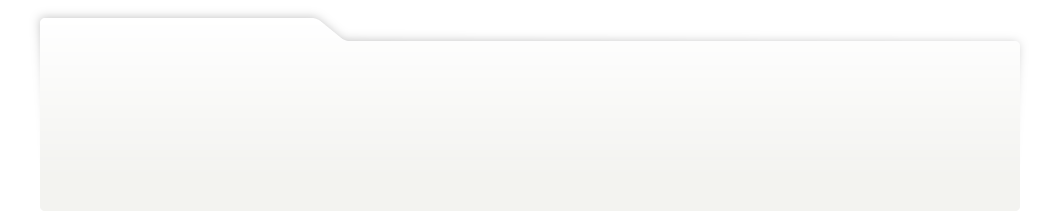
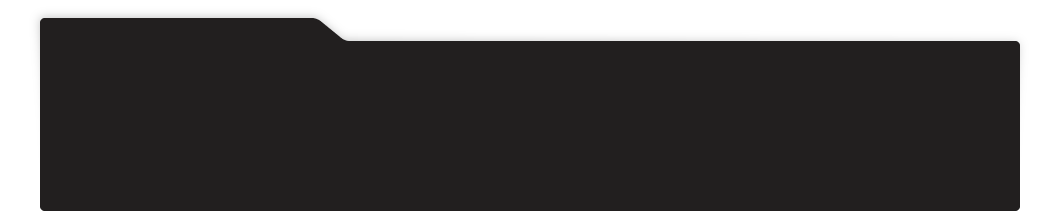
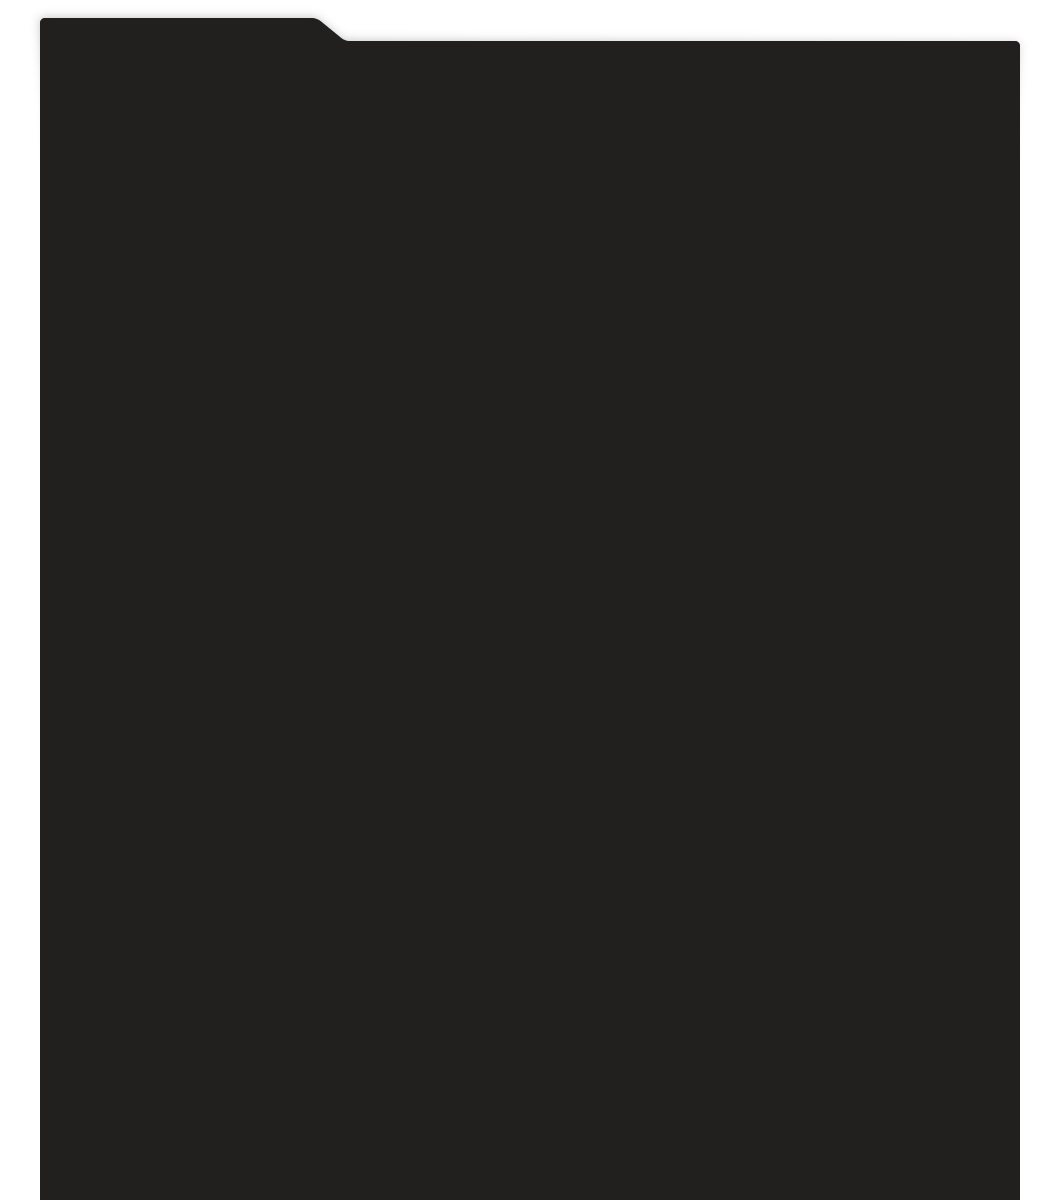
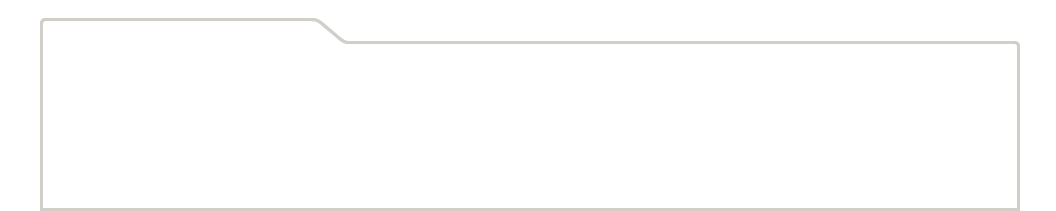
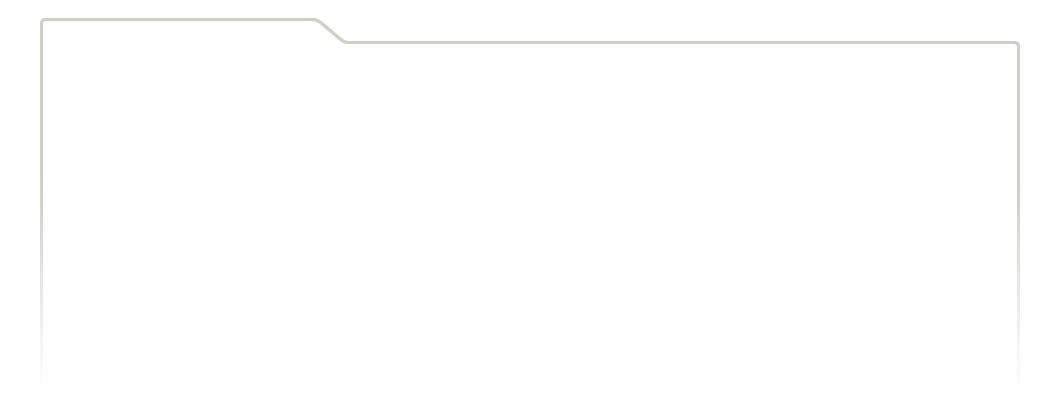
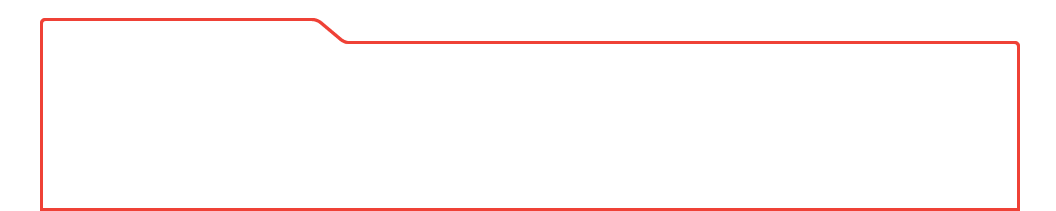
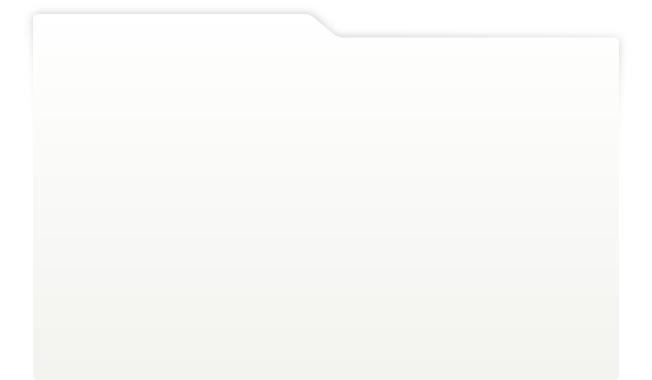
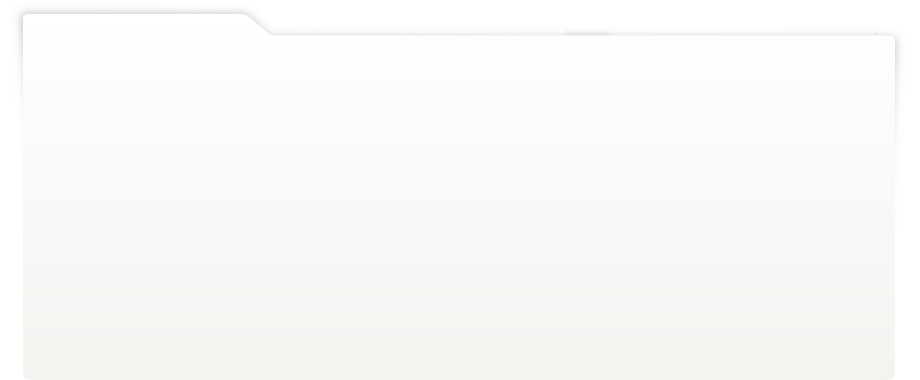
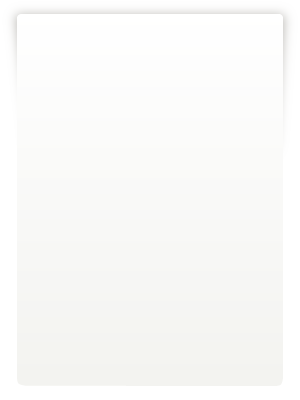
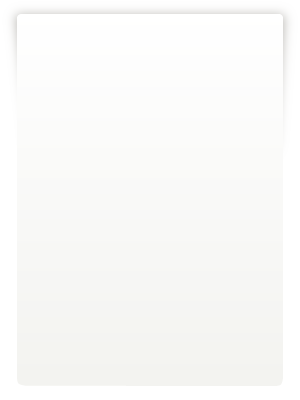
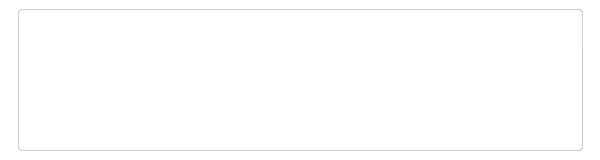
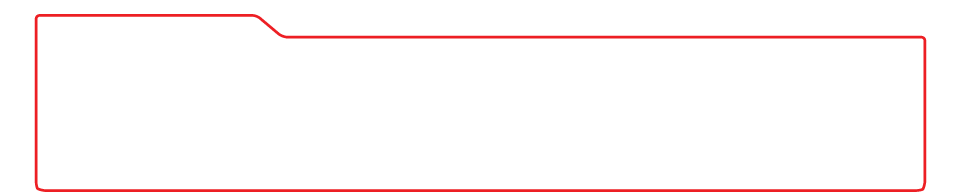
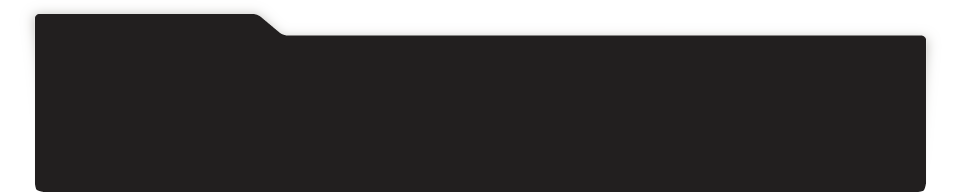
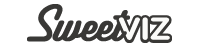
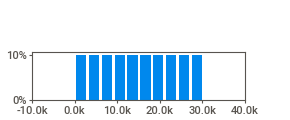
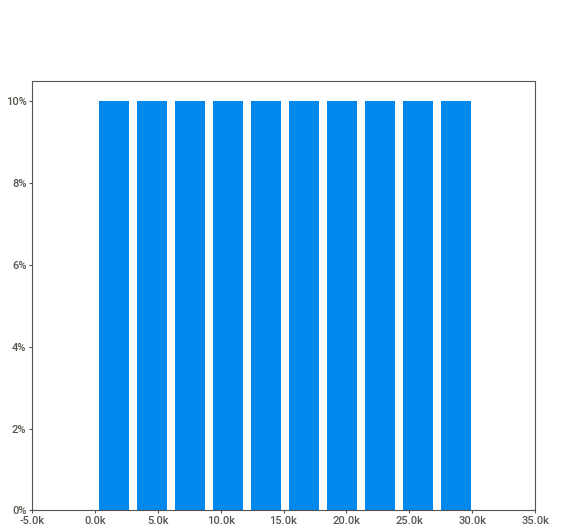
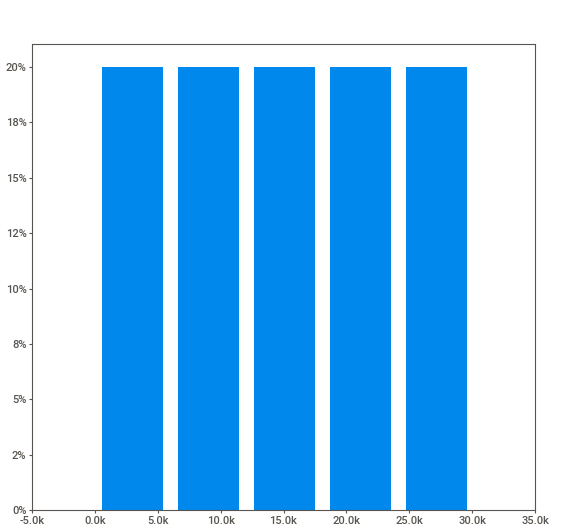
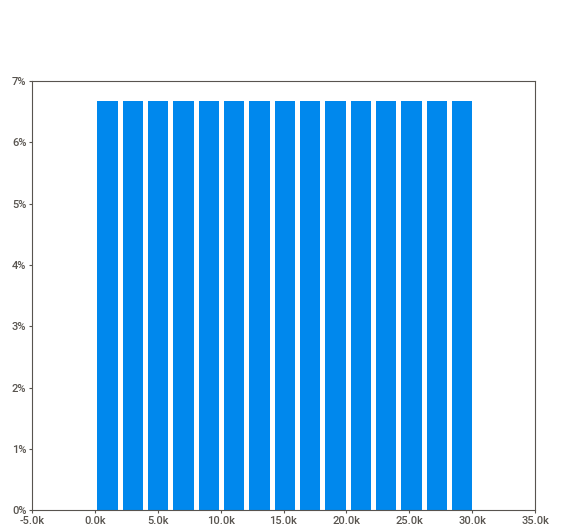
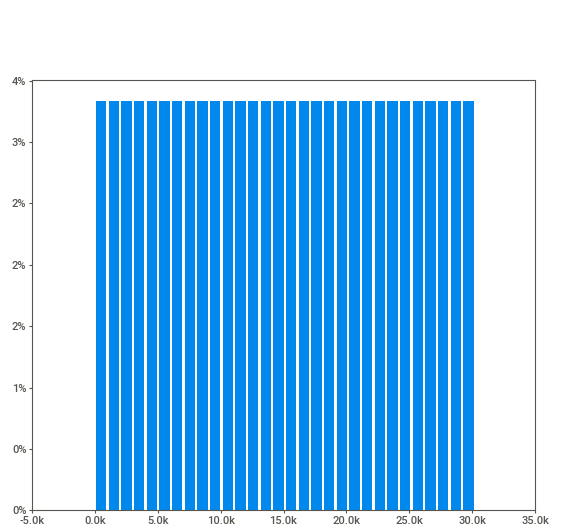
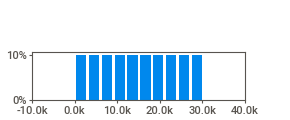
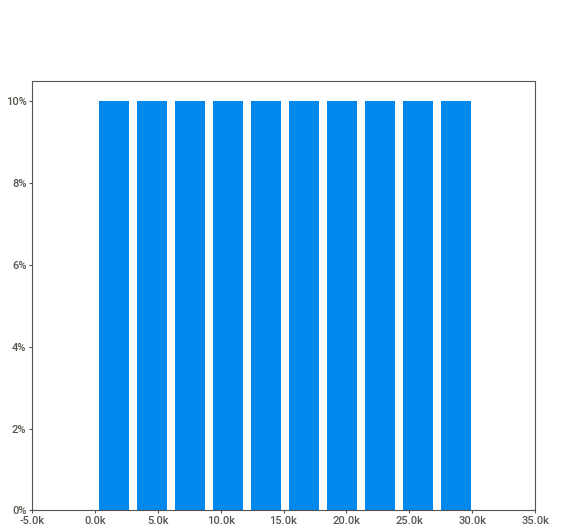
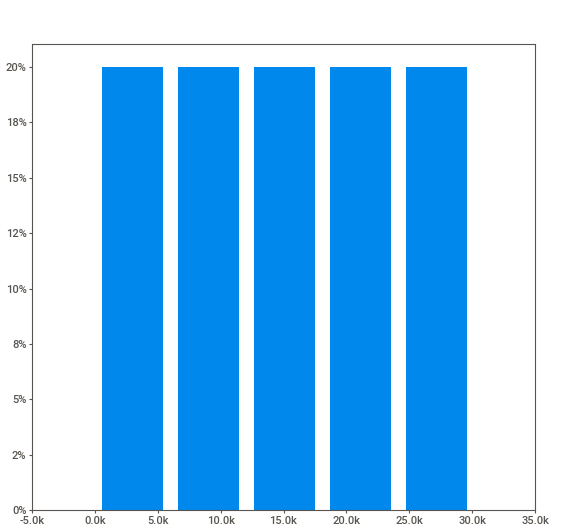
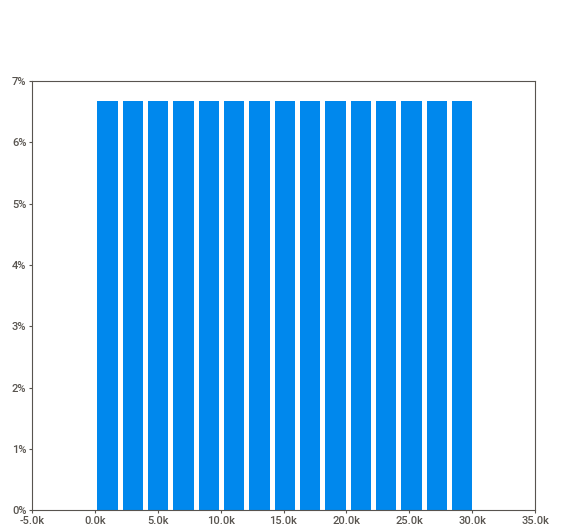
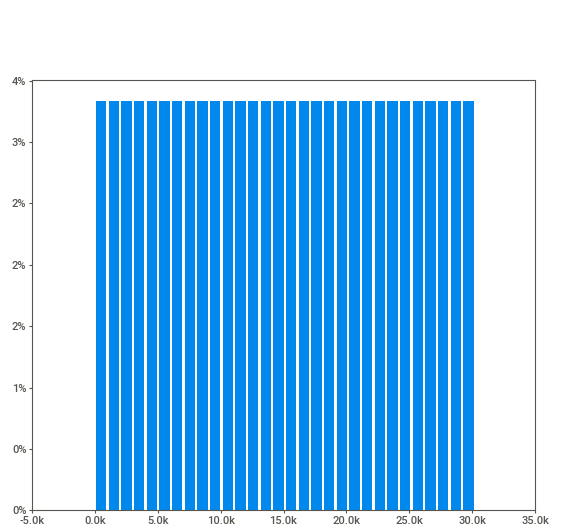
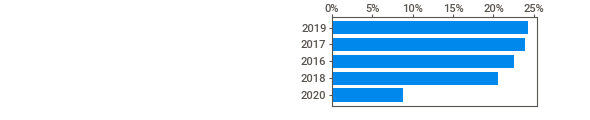
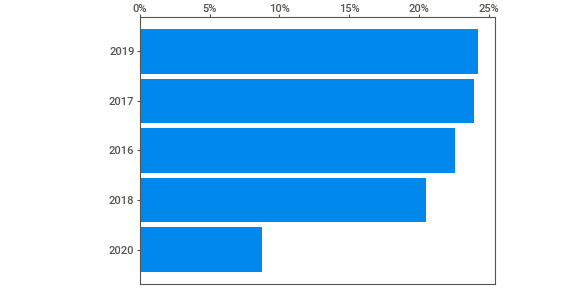
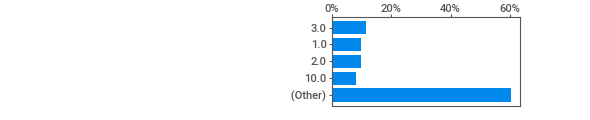
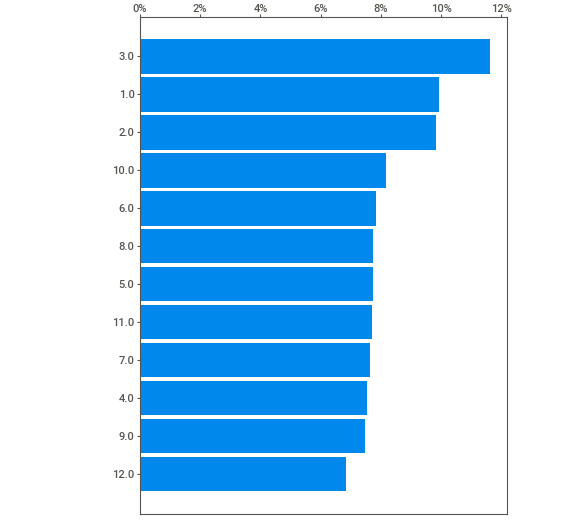
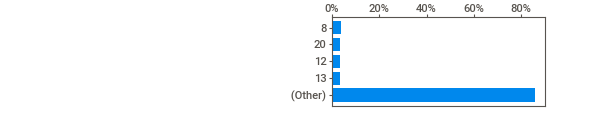
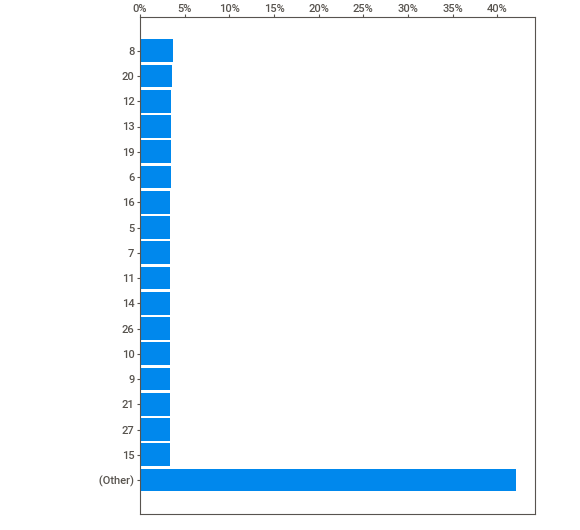
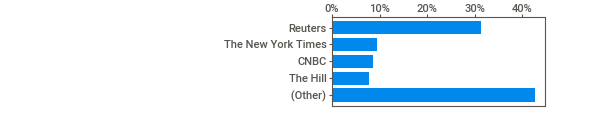
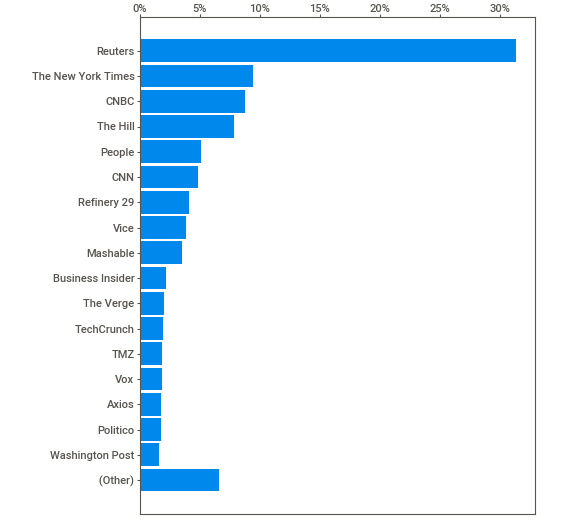
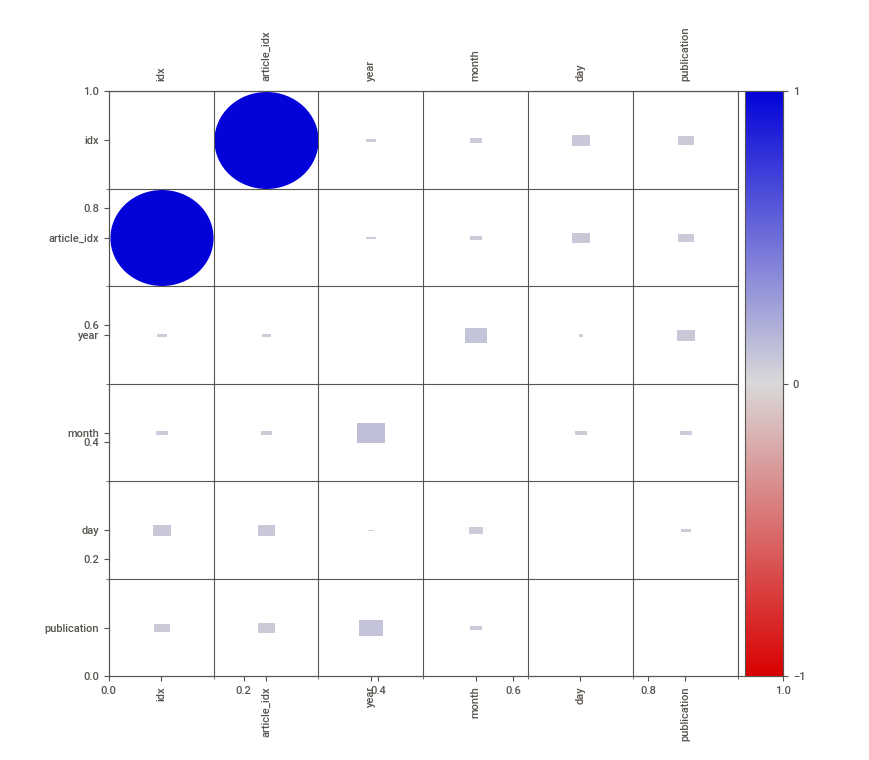
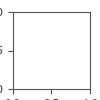

In [27]:
# Reporte automático de calidad de datos con sweetviz
# Si no está instalado: uv add sweetviz

report = swv.analyze(df)
report.show_notebook()

## Chequeos manuales de calidad

In [28]:
import re

print("1. Redundancia entre idx y article_idx?")
# Tiene sentido tener esas dos columnas idx y article idx? Parece que son lo mismo?
n_diff = (df['idx'] != df['article_idx']).sum()
print(f"   Filas donde idx != article_idx: {n_diff}")
if n_diff == 0:
    print("Columnas idénticas. Parece haber redundancia en estas dos columnas.")
else:
    display(df[df['idx'] != df['article_idx']][['idx', 'article_idx']].head())

print("-------------------------------")

print("2. Formatos distintos en la columna date?")
# Cuantos formatos distintos de fecha hay en la columna date?
iso_date     = df['date'].str.match(r'^\d{4}-\d{2}-\d{2}$')
iso_datetime = df['date'].str.match(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$')
other_fmt    = ~(iso_date | iso_datetime)
print(f"   YYYY-MM-DD             : {iso_date.sum()}")
print(f"   YYYY-MM-DD HH:MM:SS    : {iso_datetime.sum()}")
print(f"   Otro formato           : {other_fmt.sum()}")
if other_fmt.sum() > 0:
    print("   Ejemplos:")
    display(df.loc[other_fmt, 'date'].head(5))

print("-------------------------------")

print("3. Por qué month está como float?")
print(f"   dtype: {df['month'].dtype}")
print(f"   NaN en month: {df['month'].isnull().sum()}")
print(f"   Muestra: {sorted(df['month'].dropna().unique())[:8]}")

print("-------------------------------")

print("4. Consistencia date vs year / month / day")
date_parsed = pd.to_datetime(df['date'], errors='coerce')
year_num    = pd.to_numeric(df['year'],  errors='coerce')
month_num   = pd.to_numeric(df['month'], errors='coerce')
day_num     = pd.to_numeric(df['day'],   errors='coerce')

inc_year  = (date_parsed.dt.year  != year_num)  & date_parsed.notna() & year_num.notna()
inc_month = (date_parsed.dt.month != month_num) & date_parsed.notna() & month_num.notna()
inc_day   = (date_parsed.dt.day   != day_num)   & date_parsed.notna() & day_num.notna()

print(f"   Año  inconsistente: {inc_year.sum()}")
print(f"   Mes  inconsistente: {inc_month.sum()}")
print(f"   Día  inconsistente: {inc_day.sum()}")
if (inc_year | inc_month | inc_day).any():
    display(df.loc[inc_year | inc_month | inc_day, ['date','year','month','day']].head(5))
print("year/month/day son redundantes con 'date'; se pueden eliminar.")

print("-------------------------------")

print("5. Validación de URLs")
url_re  = re.compile(r'^https?://[^\s/$.?#][^\s]*$')
has_url = df['url'].notna()
valid   = df.loc[has_url, 'url'].apply(lambda x: bool(url_re.match(str(x))))
print(f"   URLs presentes : {has_url.sum()}")
print(f"   URLs válidas   : {valid.sum()} ({valid.mean()*100:.1f}%)")
print(f"   URLs inválidas : {(~valid).sum()}")
if (~valid).sum() > 0:
    display(df.loc[has_url][~valid][['url', 'publication']].head(10))

1. Redundancia entre idx y article_idx?
   Filas donde idx != article_idx: 0
Columnas idénticas. Parece haber redundancia en estas dos columnas.
-------------------------------
2. Formatos distintos en la columna date?
   YYYY-MM-DD             : 10799
   YYYY-MM-DD HH:MM:SS    : 19414
   Otro formato           : 0
-------------------------------
3. Por qué month está como float?
   dtype: str
   NaN en month: 0
   Muestra: ['1.0', '10.0', '11.0', '12.0', '2.0', '3.0', '4.0', '5.0']
-------------------------------
4. Consistencia date vs year / month / day
   Año  inconsistente: 0
   Mes  inconsistente: 0
   Día  inconsistente: 0
year/month/day son redundantes con 'date'; se pueden eliminar.
-------------------------------
5. Validación de URLs
   URLs presentes : 30072
   URLs válidas   : 30072 (100.0%)
   URLs inválidas : 0


In [29]:
# Analice la cantidad de artículos por medio de prensa
articles_per_pub = df['publication'].value_counts()

print(f"Total de medios de prensa: {len(articles_per_pub)}")
print(f"\nDistribución de artículos por medio:")
display(articles_per_pub.to_frame('Artículos'))

# Los 5 medios con más articulos
top_5_publications = articles_per_pub.head(5).index.tolist()
df_top_5 = df[df['publication'].isin(top_5_publications)].copy()

Total de medios de prensa: 26

Distribución de artículos por medio:


,Artículos
publication,
Reuters,9431
The New York Times,2840
CNBC,2623
The Hill,2349
People,1528
CNN,1446
Refinery 29,1236
Vice,1154
Mashable,1045


## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

Fechas no parseadas: 0 (0.0%)


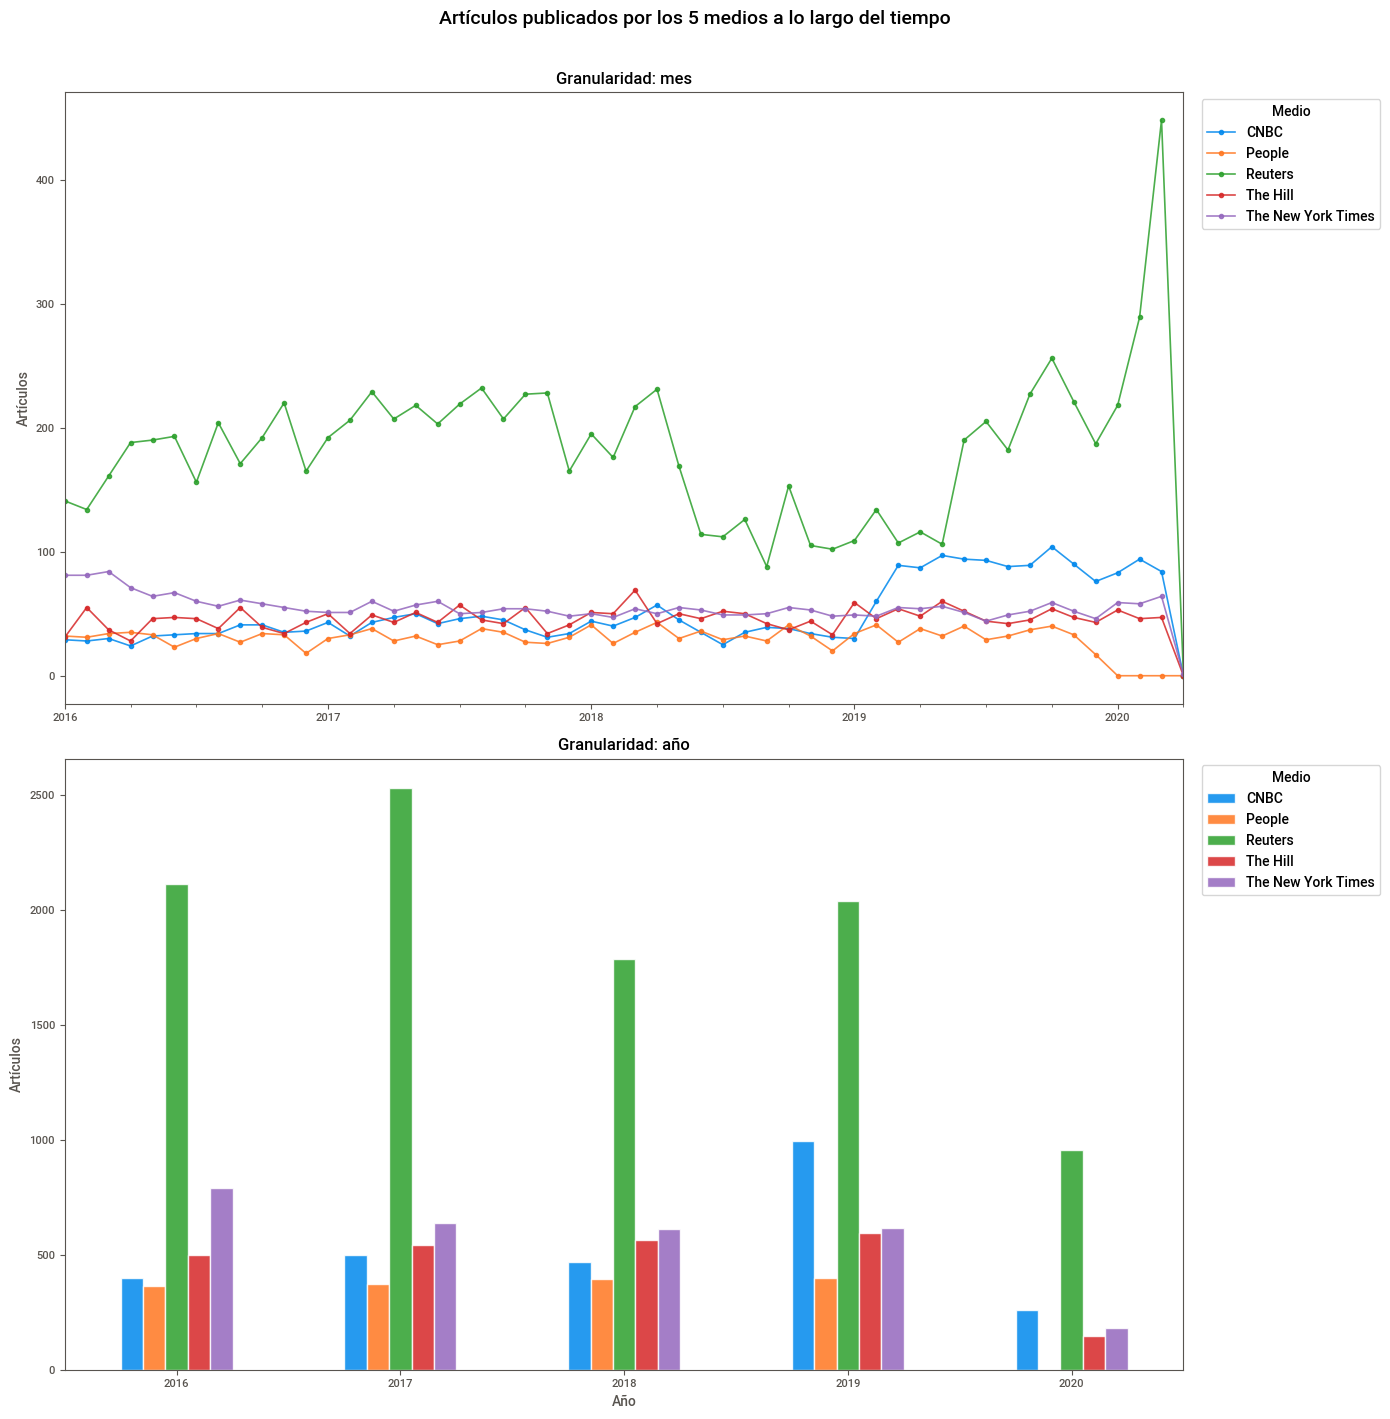

In [30]:
# Normalizar columna date: format='mixed' para manejar YYYY-MM-DD y YYYY-MM-DD HH:MM:SS
df_top_5['date_parsed'] = pd.to_datetime(df_top_5['date'], errors='coerce', format='mixed')
df_top_5['date_day']    = df_top_5['date_parsed'].dt.to_period('D')
df_top_5['date_month']  = df_top_5['date_parsed'].dt.to_period('M')
df_top_5['date_year']   = df_top_5['date_parsed'].dt.to_period('Y')

# Ver si alguna es NaT luego de la normalizada
n_unparsed = df_top_5['date_parsed'].isna().sum()
print(f"Fechas no parseadas: {n_unparsed} ({n_unparsed/len(df_top_5)*100:.1f}%)")

def count_by_period(period_col):
    return (
        df_top_5.groupby([period_col, 'publication'])
        .size()
        .unstack(fill_value=0)
        .sort_index()
    )

counts_day   = count_by_period('date_day')
counts_month = count_by_period('date_month')
counts_year  = count_by_period('date_year')

fig, axes = plt.subplots(2, 1, figsize=(14, 14))
fig.suptitle('Artículos publicados por los 5 medios a lo largo del tiempo', fontsize=14, y=1.01)

# Por mes
counts_month.plot(ax=axes[0], linewidth=1.2, alpha=0.85, marker='o', markersize=3)
axes[0].set_title('Granularidad: mes')
axes[0].set_xlabel('')
axes[0].set_ylabel('Artículos')
axes[0].legend(title='Medio', bbox_to_anchor=(1.01, 1), loc='upper left')

# Por año
counts_year.plot(ax=axes[1], kind='bar', alpha=0.85, edgecolor='white')
axes[1].set_title('Granularidad: año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Artículos')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Medio', bbox_to_anchor=(1.01, 1), loc='upper left')


plt.tight_layout()
plt.show()

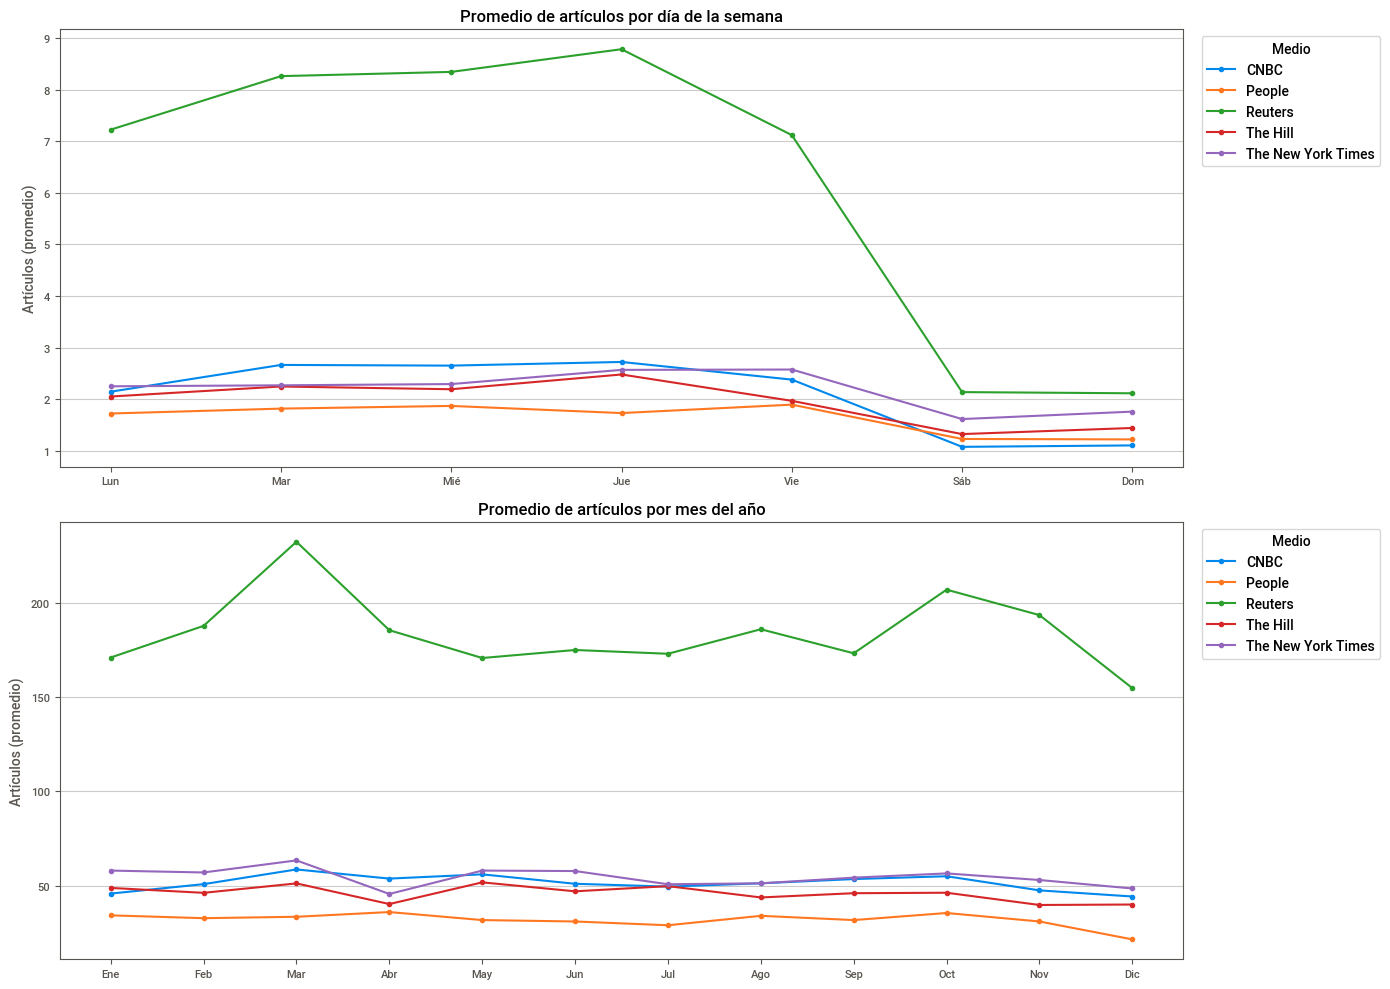

In [31]:
# Patrones cíclicos: día de la semana y mes del año
df_top_5['dow']         = df_top_5['date_parsed'].dt.dayofweek   # 0=lunes … 6=domingo
df_top_5['month_of_yr'] = df_top_5['date_parsed'].dt.month

day_names   = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
month_names = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

avg_dow = (
    df_top_5.groupby(['date_day', 'dow', 'publication'])
    .size()
    .reset_index(name='n')
    .groupby(['dow', 'publication'])['n']
    .mean()
    .unstack()
)
avg_dow.index = [day_names[i] for i in avg_dow.index]

avg_month = (
    df_top_5.groupby(['date_month', 'month_of_yr', 'publication'])
    .size()
    .reset_index(name='n')
    .groupby(['month_of_yr', 'publication'])['n']
    .mean()
    .unstack()
)
avg_month.index = [month_names[i-1] for i in avg_month.index]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

avg_dow.plot(ax=axes[0], marker='o', linewidth=1.5)
axes[0].set_title('Promedio de artículos por día de la semana')
axes[0].set_ylabel('Artículos (promedio)')
axes[0].set_xlabel('')
axes[0].legend(title='Medio', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].grid(axis='y', alpha=0.3)

avg_month.plot(ax=axes[1], marker='o', linewidth=1.5)
axes[1].set_title('Promedio de artículos por mes del año')
axes[1].set_ylabel('Artículos (promedio)')
axes[1].set_xlabel('')
axes[1].set_xticks(range(len(avg_month)))
axes[1].set_xticklabels(avg_month.index)
axes[1].legend(title='Medio', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [32]:
def clean_text(df, column_name):

    # Eliminar primeras palabras hasta el primer "\n"
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # Eliminar URLs (http/https): en artículos de noticias aparecen links que no aportan
    # información léxica para clasificación por medio de prensa
    result = result.str.replace(r'https?://\S+', ' ', regex=True)

    # Eliminar todos los signos de puntuación y caracteres no alfanuméricos.
    # El loop original solo cubría 5 símbolos ("[", "\n", ",", ":", "?"); con el patrón
    # [^\w\s] se capturan en un solo paso: . ! ; ( ) [ ] { } " ' - _ / | < > # @ % & * + = ^ ~ `
    # Reemplazar por espacio evita que dos palabras queden pegadas al eliminar un guion o barra.
    result = result.str.replace(r'[^\w\s]', ' ', regex=True)

    # Eliminar números aislados (dígitos solos): fechas, cifras y porcentajes no ayudan
    # a discriminar el estilo editorial de cada medio.
    result = result.str.replace(r'\b\d+\b', ' ', regex=True)

    # Normalizar saltos de línea y tabulaciones a espacios
    result = result.str.replace(r'[\n\r\t]', ' ', regex=True)

    # Colapsar múltiples espacios consecutivos en uno solo
    result = result.str.replace(r'\s+', ' ', regex=True)

    # Eliminar espacios al inicio y al final de cada texto
    result = result.str.strip()

    return result

In [33]:
# Aplicar clean_text sobre la columna "article" y guardar en "CleanText"
df_top_5["CleanText"] = clean_text(df_top_5, "article")

# Verificar resultado: comparar texto original vs. limpio en 3 artículos
for i, row in df_top_5[["article", "CleanText", "publication"]].dropna().head(3).iterrows():
    print(f"=== [{row['publication']}] ===")
    print("ORIGINAL :", repr(row["article"][:200]))
    print("LIMPIO   :", repr(row["CleanText"][:200]))
    print()

=== [Reuters] ===
ORIGINAL : 'Feb 2 (Reuters) - Teva Pharmaceutical Industries Ltd : * EUROPEAN MEDICINES AGENCY (EMA) ACCEPTS FREMANEZUMAB MARKETING AUTHORIZATION APPLICATION Source text for Eikon: Further company coverage:'
LIMPIO   : 'feb reuters teva pharmaceutical industries ltd european medicines agency ema accepts fremanezumab marketing authorization application source text for eikon further company coverage'

=== [CNBC] ===
ORIGINAL : "The head of the Centers for Medicare and Medicaid Services said Monday it's time that health care catches up with other industries when it comes to providing consumers greater transparency about price"
LIMPIO   : 'the head of the centers for medicare and medicaid services said monday it s time that health care catches up with other industries when it comes to providing consumers greater transparency about price'

=== [The Hill] ===
ORIGINAL : 'Benchmark, the venture capital firm that helped push Travis Kalanick out of Uber, told the company’s emp

## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

Se eligió trabajar con el **cuerpo del artículo** (`article`).

El objetivo del análisis es construir un perfil de palabras que permita distinguir un medio de otro. Para eso, el volumen de texto importa: los títulos tienen en promedio unas 10 palabras, lo que genera perfiles de frecuencia muy ruidosos y dependientes del tema puntual de cada nota. El cuerpo del artículo tiene entre 200 y 900 palabras según el medio, lo que da mucha más señal para caracterizar el estilo editorial real.

Además, el cuerpo captura cosas que el título no: vocabulario técnico, estructura de los párrafos, referencias cruzadas, etc. Combinar ambos campos no aporta demasiado porque el artículo ya contiene toda la información del título.

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [34]:
# 3 artículos random por medio para inspección visual
for pub in top_5_publications:
    sub = df_top_5[df_top_5["publication"] == pub].dropna(subset=["article"]).sample(3)
    print(f"\n{'='*70}")
    print(f"  {pub.upper()}")
    print(f"{'='*70}")
    for _, row in sub.iterrows():
        print(f"DATE    : {row['date']}")
        print(f"SECTION : {row['section']}")
        print(f"AUTHOR  : {row['author']}")
        print(f"URL     : {row['url']}")
        print(f"TITLE   : {row['title']}")
        print(f"ARTICLE :\n{row['article']}")
        print("-"*50)


  REUTERS
DATE    : 2017-07-15
SECTION : World News
AUTHOR  : nan
URL     : https://www.reuters.com/article/us-zimbabwe-mugabe-wife-idUSKBN1A00D6
TITLE   : Zimbabwe's first lady injures ankle in 'freak' car accident
ARTICLE :
HARARE (Reuters) - Zimbabwean President Robert Mugabe’s wife Grace was injured in what officials called a freak accident as she left the airport with her husband on Saturday following their return from Singapore, state television reported. Mugabe had gone to Singapore on July 7 for a medical check, his third such trip this year and was accompanied by his wife. State television ZBC quoted Mugabe’s spokesman George Charamba saying that the veteran leader’s wife “suffered some soft tissue bruising on the right ankle as a result of a freak car incident at the Harare International Airport soon after arrival” from Singapore. “The accident occurred as the First Family was about to leave the airport for the residence,” ZBC reported on its website, without giving details 

In [35]:
arts = df_top_5[["publication", "title", "article"]].dropna(subset=["article"])

# Cada entrada en checks es una lista de patrones a buscar por medio.
# Cada patrón es una tupla de 4 elementos:
#   (label, pattern, is_regex, col)
#   - label    : descripción del patrón (para imprimir)
#   - pattern  : string o regex a buscar
#   - is_regex : True si pattern es una expresión regular, False si es literal
#   - col      : columna donde buscar ("article" o "title")
checks = {
    "Reuters": [
        ("dateline (Reuters) en cuerpo",        r"\(Reuters\)",                  True,  "article"),
        ("firma 'Reporting by X; Editing by Y'", "Reporting by",                 False, "article"),
        ("plantilla 'Further company coverage'", "Further company",              False, "article"),
    ],
    "The Hill": [
        ("sufijo '| TheHill' en título",        r"\| TheHill",                   True,  "title"),
        ("footer legal 'Capitol Hill Pub.'",    "Capitol Hill Publishing Corp",  False, "article"),
        ("URL thehill.com en cuerpo",           "thehill.com",                   False, "article"),
        ("nombres de políticos duplicados",     r"([A-Z][a-z]+ [A-Z][a-z]+)\1", True,  "article"),
    ],
    "CNBC": [
        ("(Reuters) en cuerpo (cable republ.)", r"\(Reuters\)",                  True,  "article"),
        ("firma 'Reporting by' (cable)",        "Reporting by",                  False, "article"),
        ("plantilla footer Mad Money",          "madcap@cnbc.com",               False, "article"),
        ("'CNBC' mencionado en cuerpo",         "CNBC",                          False, "article"),
        ("URL cnbc.com en cuerpo",              "cnbc.com",                      False, "article"),
    ],
    "The New York Times": [
        ("'New York Times' mencionado",         "New York Times",                False, "article"),
        ("URL nytimes.com en cuerpo",           "nytimes.com",                   False, "article"),
        ("plantilla footer Opinion (@NYTopinion)", "NYTopinion",                 False, "article"),
        ("plantilla footer Learning Network",  "Learning Network",               False, "article"),
        ("plantilla footer NY Today columna",  "New York Today",                 False, "article"),
    ],
    "People": [
        ("firma 'tells/told PEOPLE' en citas",  r"tells PEOPLE|told PEOPLE",    True,  "article"),
        ("'PEOPLE' en mayúsculas en cuerpo",    "PEOPLE",                        False, "article"),
        ("plantilla footer 'PEOPLE Now'",       "PEOPLE Now",                    False, "article"),
        ("URL people.com en cuerpo",            "people.com",                    False, "article"),
    ],
}

for pub, patterns in checks.items():
    mask  = arts["publication"] == pub
    total = mask.sum()
    print(f"\n{'─'*60}  {pub}")
    for label, pattern, is_regex, col in patterns:
        n = arts.loc[mask, col].str.contains(pattern, regex=is_regex, na=False).sum()
        print(f"  {label:50s}: {n:4d} / {total}  ({n/total*100:.0f}%)")


────────────────────────────────────────────────────────────  Reuters
  dateline (Reuters) en cuerpo                      : 8520 / 9272  (92%)
  firma 'Reporting by X; Editing by Y'              : 5201 / 9272  (56%)
  plantilla 'Further company coverage'              : 2248 / 9272  (24%)

────────────────────────────────────────────────────────────  The Hill
  sufijo '| TheHill' en título                      : 2349 / 2349  (100%)
  footer legal 'Capitol Hill Pub.'                  : 2335 / 2349  (99%)
  URL thehill.com en cuerpo                         :   43 / 2349  (2%)


/var/folders/24/h6503xm50k9_ttkxnpbmggmm0000gn/T/ipykernel_37538/2148472411.py:49: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  n = arts.loc[mask, col].str.contains(pattern, regex=is_regex, na=False).sum()


  nombres de políticos duplicados                   :  386 / 2349  (16%)

────────────────────────────────────────────────────────────  CNBC
  (Reuters) en cuerpo (cable republ.)               :  626 / 2578  (24%)
  firma 'Reporting by' (cable)                      :  501 / 2578  (19%)
  plantilla footer Mad Money                        :   58 / 2578  (2%)
  'CNBC' mencionado en cuerpo                       :  898 / 2578  (35%)
  URL cnbc.com en cuerpo                            :   72 / 2578  (3%)

────────────────────────────────────────────────────────────  The New York Times
  'New York Times' mencionado                       :  531 / 2810  (19%)
  URL nytimes.com en cuerpo                         :  235 / 2810  (8%)
  plantilla footer Opinion (@NYTopinion)            :   86 / 2810  (3%)
  plantilla footer Learning Network                 :   20 / 2810  (1%)
  plantilla footer NY Today columna                 :   28 / 2810  (1%)

────────────────────────────────────────────────────

Revisando los artículos se identificaron los siguientes patrones que identifican directamente al medio:

**Reuters:** el 92% de los artículos tiene el dateline `CIUDAD (Reuters) -` en el cuerpo. El 56% termina con la firma `Reporting by X; Editing by Y` y el 24% tiene la plantilla `Further company coverage:`. Son tres marcas acumuladas que identifican a Reuters de forma casi inequívoca.

**The Hill:** dos pistas 100% sistemáticas: todos los títulos terminan en `| TheHill` y el 99% de los artículos termina con el mismo footer legal que incluye la dirección física, teléfonos y copyright (`Capitol Hill Publishing Corp.`). Además el 2% de artículos incluye la URL `thehill.com` en el cuerpo, y hay un artefacto del scraping donde los nombres de políticos quedan duplicados (`John McCainJohn Sidney McCain`).

**CNBC:** el 24% de sus artículos son cables de Reuters republicados y tienen tanto el dateline `(Reuters)` como la firma `Reporting by`. El 35% menciona "CNBC" en el cuerpo. Hay un footer recurrente del segmento Mad Money que termina con `madcap@cnbc.com`. No hay un boilerplate tan uniforme como en Reuters o The Hill para el contenido original.

**NYT:** el 19% menciona "New York Times" y el 8% incluye `nytimes.com`. A diferencia de los otros medios, las pistas no son un boilerplate único sino footers específicos por sección: artículos de Opinion terminan con `@NYTopinion`, los de Learning Network con "Learning Network staff", y los de la columna NY Today con "New York Today". Cada uno representa un porcentaje pequeño pero son señales directas del medio.

**People:** el 28% usa `tells PEOPLE` o `told PEOPLE` en las citas, que es la convención editorial de la revista para atribuir fuentes. El 50% menciona "PEOPLE" en mayúsculas. Hay un footer recurrente que menciona "PEOPLE Now" (su programa de streaming). Las URLs propias (`people.com`) aparecen en solo el 1% de los artículos.

**Columna `url`:** el dominio de la URL identifica al medio al 100% en todos los casos. Sin embargo es metadata del dataset y no texto del artículo, por lo que usarla como feature en clasificación sería hacer trampa.

**Columna `section`:** útil para Reuters (99% de cobertura, secciones propias como "Market News"), NYT (98%) y People (100%), pero tiene 18% de nulos en CNBC y está completamente ausente en The Hill. No filtra al cuerpo del artículo de forma sistemática.

**¿Conviene eliminar las pistas del texto?** Para un clasificador que aprenda estilo editorial real, sí conviene eliminarlas, especialmente el dateline de Reuters y el footer de The Hill, que hacen la clasificación trivial para esos dos medios. En el contexto de este trabajo exploratorio se dejan, pero se reporta su efecto.

In [36]:
# Verificación cruzada: ¿los patrones de un medio aparecen también en los otros?
# Filas = patrón identificador, Columnas = medio donde se busca
cross_checks = {
    "Reuters dateline '(Reuters)'":   (r"\(Reuters\)",                True,  "article"),
    "The Hill '| TheHill' en título": (r"\| TheHill",                 True,  "title"),
    "The Hill footer Capitol Hill":   ("Capitol Hill Publishing Corp", False, "article"),
    "CNBC mencionado en cuerpo":      ("CNBC",                        False, "article"),
    "NYT 'nytimes.com' en cuerpo":    ("nytimes.com",                 False, "article"),
    "People 'tells/told PEOPLE'":     (r"tells PEOPLE|told PEOPLE",   True,  "article"),
}

rows = []
for label, (pattern, is_regex, col) in cross_checks.items():
    row = {"patrón": label}
    for pub in top_5_publications:
        mask  = arts["publication"] == pub
        n     = arts.loc[mask, col].str.contains(pattern, regex=is_regex, na=False).sum()
        total = mask.sum()
        row[pub] = f"{n/total*100:.0f}%"
    rows.append(row)

pd.DataFrame(rows).set_index("patrón")

,Reuters,The New York Times,CNBC,The Hill,People
patrón,,,,,
Reuters dateline '(Reuters)',92%,0%,24%,0%,0%
The Hill '| TheHill' en título,0%,0%,0%,100%,0%
The Hill footer Capitol Hill,0%,0%,0%,99%,0%
CNBC mencionado en cuerpo,0%,0%,35%,1%,0%
NYT 'nytimes.com' en cuerpo,0%,8%,0%,0%,0%
People 'tells/told PEOPLE',0%,0%,0%,0%,28%


## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

**Restricción por sección temática**

La idea de restringir por sección es interesante en principio: si se comparan artículos del mismo tema, cualquier diferencia en frecuencia de palabras refleja estilo editorial y no simplemente el topic. Sin embargo, en este dataset hay dos problemas concretos que lo hacen inviable:

- **People cubre exclusivamente entretenimiento** (tv, movies, celebrity, style) y no tiene artículos de política ni economía, que son los temas dominantes en los otros cuatro medios. Restringir por sección equivaldría a eliminar People del análisis.
- **The Hill no tiene datos de sección** en ninguno de sus artículos.

Además, el tema que cubre cada medio es parte de su identidad editorial: Reuters es una agencia de cable financiera, People es una revista de celebrities. Esa diferencia temática no es ruido sino una característica real del medio.

**Restricción por período temporal**

Los cinco medios cubren aproximadamente el mismo período (2016 a 2020), con distribución bastante uniforme. No hay un argumento fuerte para acotarlo. Restringir a un año en particular reduciría el tamaño de muestra sin eliminar el problema del sesgo temático, que es la razón principal por la que se evaluaría esta restricción.

# Parte 2: Conteo de Palabras y Visualizaciones

## Preparación: tokens limpios para la Parte 2

Para los conteos de palabras de la Parte 2 conviene partir de tokens ya filtrados:

- Se eliminan las **stopwords** en inglés (artículos, preposiciones, conjunciones), porque dominan el ranking de frecuencias y no diferencian un medio de otro.
- Se eliminan los **identificadores del medio** detectados en la sección 1.E (`reuters`, `cnbc`, `nytimes`, `nyt`, `thehill`, etc.). Si no se removieran, esas palabras delatarían trivialmente al medio y empobrecerían cualquier análisis de estilo editorial o de tema.

Se define `clean_text_v2(...)` que aplica `clean_text(...)` y devuelve una serie de listas de tokens ya filtrados. Se reutilizará en las partes 2.A, 2.B y 2.C.


In [37]:
import re
import nltk
from collections import Counter

try:
    from nltk.corpus import stopwords
    _ = stopwords.words("english")
except LookupError:
    nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords as _nltk_stopwords

STOPWORDS_EN = set(_nltk_stopwords.words("english"))

# Identificadores del medio detectados en 1.E. Se filtran a nivel de token aislado:
# cuando aparecen como palabra suelta se eliminan para que no delaten trivialmente al medio.
MEDIA_IDENTIFIERS = {
    "Reuters":            {"reuters", "reporting", "editing"},
    "The Hill":           {"thehill"},
    "CNBC":               {"cnbc", "madcap"},
    "The New York Times": {"nytimes", "nyt", "nytopinion"},
    "People":             {"people"},
}
ALL_MEDIA_TOKENS = set().union(*MEDIA_IDENTIFIERS.values())
EXTRA_STOPWORDS = STOPWORDS_EN | ALL_MEDIA_TOKENS

# Plantillas / boilerplate detectados en 1.E. Se eliminan ANTES de la limpieza general
# para borrar la frase completa (y no palabras sueltas como "capitol" o "hill" que
# también aparecen en otros contextos políticos genuinos).
MEDIA_BOILERPLATE_PATTERNS = [
    # Reuters: dateline al inicio del cuerpo, ej. "WASHINGTON (Reuters) - ..."
    "(?i)\\b[\\w\\s.,\'-]{0,60}?\\(reuters\\)\\s*[-–—]\\s*",
    # Reuters: firma final "Reporting by X" / "Editing by Y"
    "(?i)reporting by [^.\\n]{0,200}",
    "(?i)editing by [^.\\n]{0,200}",
    # Reuters: bloque final "Further company coverage: ..."
    "(?i)further company coverage[^\\n]{0,500}",
    # The Hill: sufijo en título "... | TheHill"
    "(?i)\\|\\s*thehill\\b",
    # The Hill: footer legal completo (incluye dirección, telefonos, copyright)
    "(?i)capitol hill publishing corp[^\\n]{0,500}",
    # CNBC: contacto del segmento Mad Money
    "(?i)madcap@cnbc\\.com",
    # NYT: handle de la sección de opinión
    "@NYTopinion",
]


def clean_text_v2(df, column_name,
                  extra_stopwords=EXTRA_STOPWORDS,
                  boilerplate_patterns=MEDIA_BOILERPLATE_PATTERNS):
    """
    Pipeline de limpieza para la Parte 2:
      1. Elimina plantillas / boilerplate del medio (1.E) sobre el texto crudo.
      2. Aplica clean_text(): minúsculas, sin puntuación / URLs / números.
      3. Tokeniza por espacios.
      4. Filtra stopwords en inglés (NLTK) + identificadores del medio que quedaron sueltos.
    Devuelve una serie de listas de tokens.
    """
    s = df[column_name].astype(object)
    for pattern in boilerplate_patterns:
        s = s.str.replace(pattern, " ", regex=True)

    df_pre = df.copy()
    df_pre[column_name] = s

    cleaned = clean_text(df_pre, column_name)
    return cleaned.apply(
        lambda x: [t for t in x.split() if t and t not in extra_stopwords]
        if isinstance(x, str) else []
    )


df_top_5["Tokens"] = clean_text_v2(df_top_5, "article")

# Comprobación rápida
n_tokens = df_top_5["Tokens"].apply(len)
print(f"Artículos                       : {len(df_top_5):,}")
print(f"Total tokens (filtrados)        : {n_tokens.sum():,}")
print(f"Promedio tokens / artículo      : {n_tokens.mean():.0f}")
print(f"Vocabulario filtrado removido   : {len(EXTRA_STOPWORDS):,} tokens "
      f"({len(STOPWORDS_EN)} stopwords + {len(ALL_MEDIA_TOKENS)} pistas del medio)")
print(f"Patrones de boilerplate         : {len(MEDIA_BOILERPLATE_PATTERNS)} (de 1.E)")


Artículos                       : 18,771
Total tokens (filtrados)        : 4,722,946
Promedio tokens / artículo      : 252
Vocabulario filtrado removido   : 208 tokens (198 stopwords + 10 pistas del medio)
Patrones de boilerplate         : 8 (de 1.E)


## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

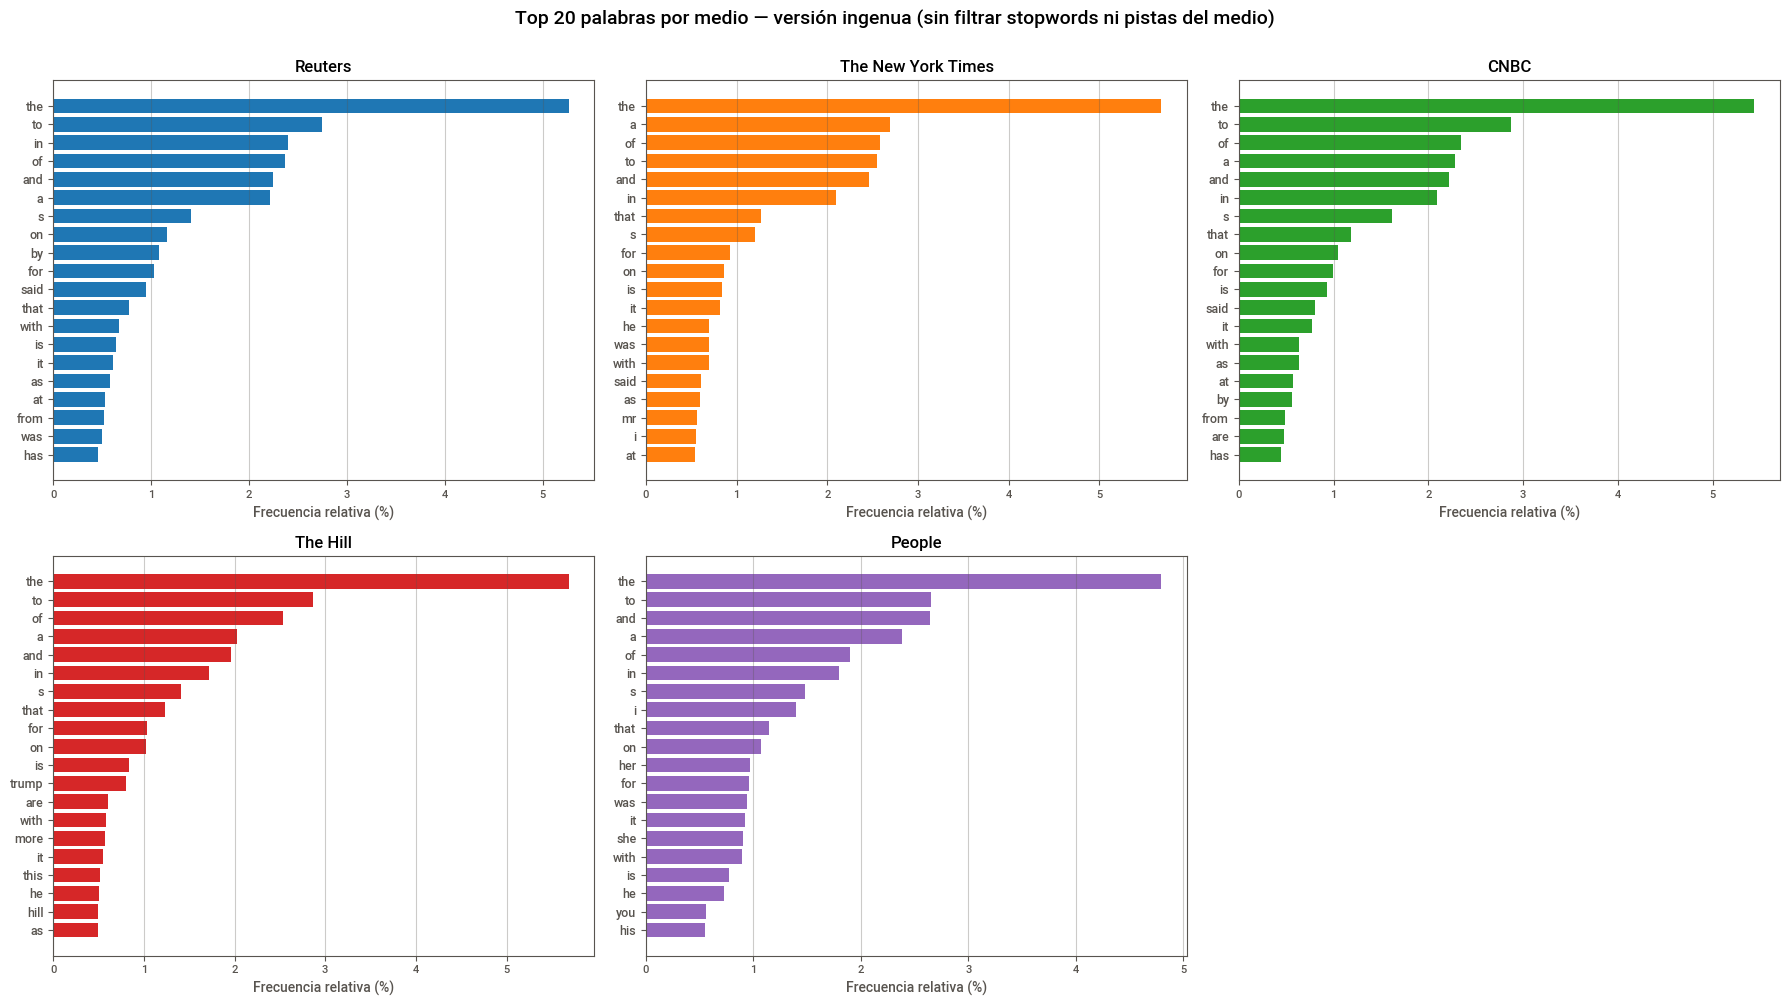

In [38]:
# 2.A — versión INGENUA: top 20 palabras por medio sobre CleanText, sin filtrar.
# Se incluye explícitamente esta versión para evidenciar el problema (stopwords + pistas)
# que se discute en la sección 2.B.

def top_words_naive(df, top_n=20):
    out = {}
    for pub in top_5_publications:
        mask = df["publication"] == pub
        counter = Counter()
        for text in df.loc[mask, "CleanText"].dropna():
            counter.update(text.split())
        total = sum(counter.values()) or 1
        out[pub] = [(w, c / total * 100) for w, c in counter.most_common(top_n)]
    return out


def plot_top_words(top_words, title, palette=None):
    if palette is None:
        palette = sns.color_palette("tab10", n_colors=len(top_words))
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes_flat = axes.flatten()
    for i, (pub, items) in enumerate(top_words.items()):
        ax = axes_flat[i]
        words, freqs = zip(*items)
        ax.barh(words[::-1], freqs[::-1], color=palette[i % len(palette)])
        ax.set_title(pub, fontsize=12)
        ax.set_xlabel("Frecuencia relativa (%)")
        ax.tick_params(axis="y", labelsize=9)
        ax.grid(axis="x", alpha=0.3)
    for j in range(len(top_words), len(axes_flat)):
        axes_flat[j].axis("off")
    fig.suptitle(title, fontsize=14, y=1.001)
    plt.tight_layout()
    plt.show()


top_naive = top_words_naive(df_top_5, top_n=20)
plot_top_words(top_naive, "Top 20 palabras por medio — versión ingenua (sin filtrar stopwords ni pistas del medio)")


**Problema observado.** Los rankings de los 5 medios son casi idénticos: aparecen las mismas palabras (*the, to, of, and, a, in, is, that, for, on, with, as, by, it, this, from*...). Son **stopwords** que dominan la masa del idioma pero no diferencian un medio de otro. Además, en algunos medios se filtra algún **identificador del medio** detectado en 1.E (por ejemplo *reuters* en Reuters).

La visualización es poco informativa: no permite comparar nada interesante entre los 5 medios. Para que sí permita comparar se construye la versión filtrada a continuación (sin stopwords ni identificadores del medio).


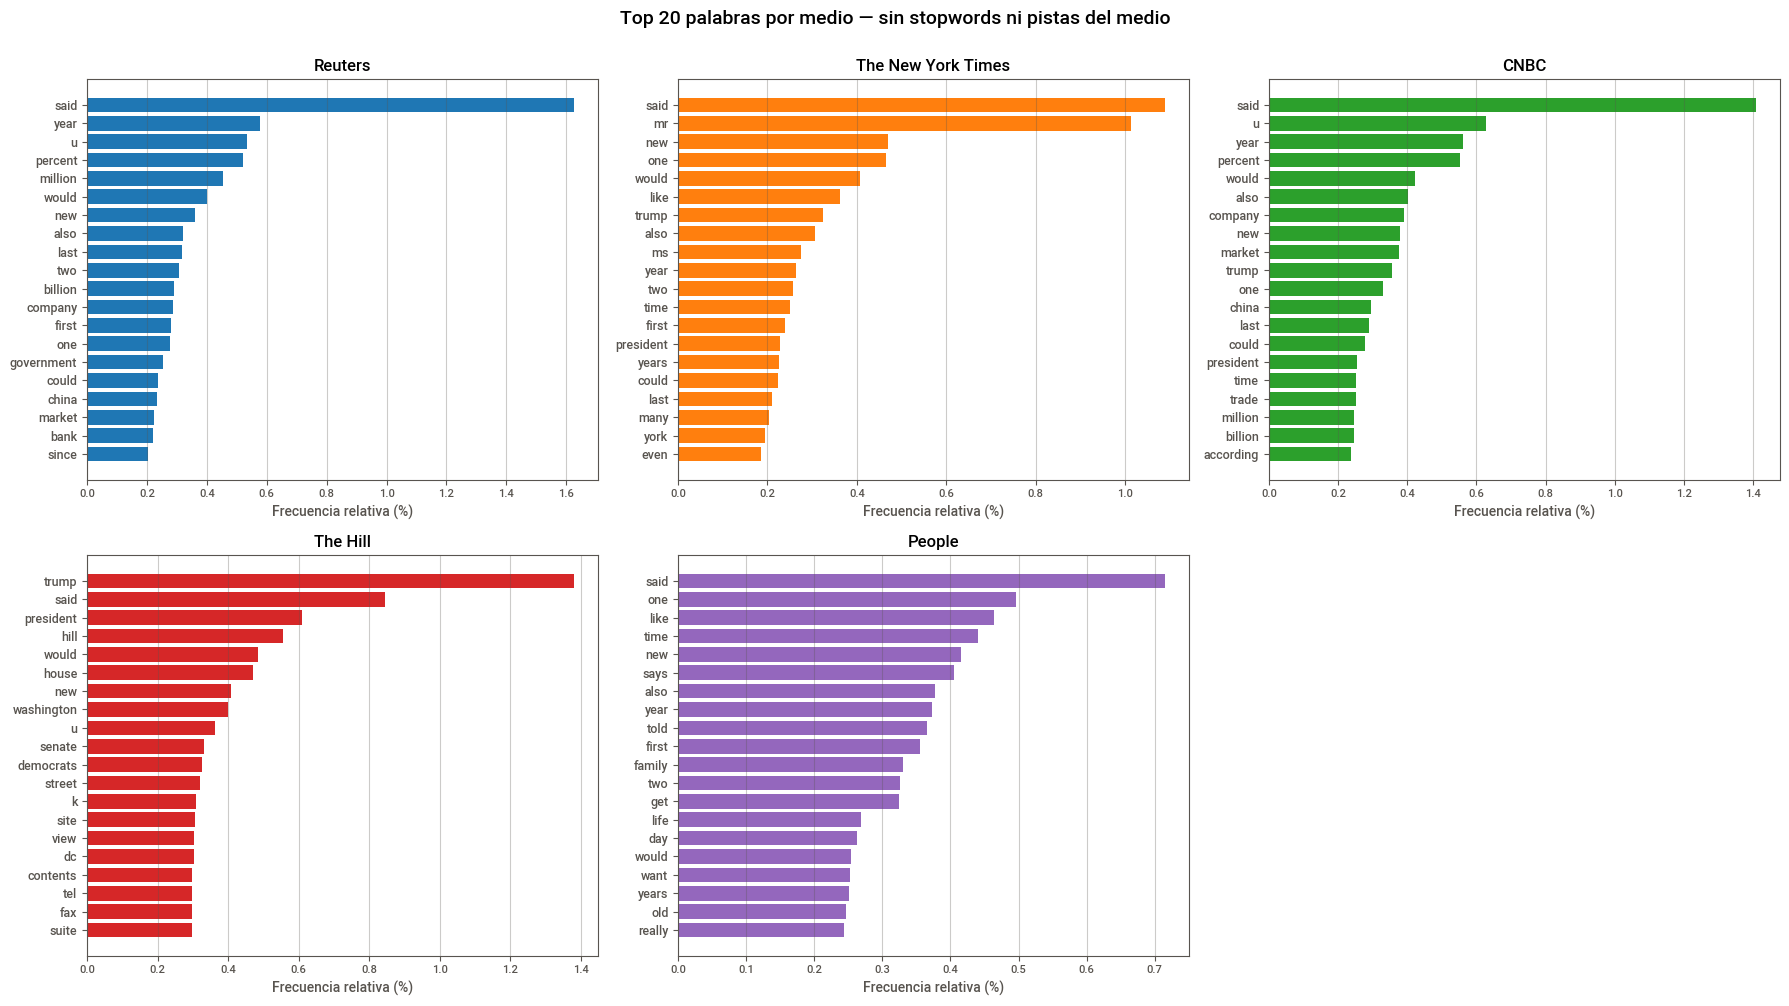

In [39]:
# 2.A — versión FILTRADA: top 20 palabras por medio sobre Tokens
# (stopwords en inglés y pistas del medio ya removidas en clean_text_v2).

def top_words_filtered(df, top_n=20):
    out = {}
    for pub in top_5_publications:
        mask = df["publication"] == pub
        counter = Counter()
        for tokens in df.loc[mask, "Tokens"]:
            counter.update(tokens)
        total = sum(counter.values()) or 1
        out[pub] = [(w, c / total * 100) for w, c in counter.most_common(top_n)]
    return out


top_clean = top_words_filtered(df_top_5, top_n=20)
plot_top_words(top_clean, "Top 20 palabras por medio — sin stopwords ni pistas del medio")


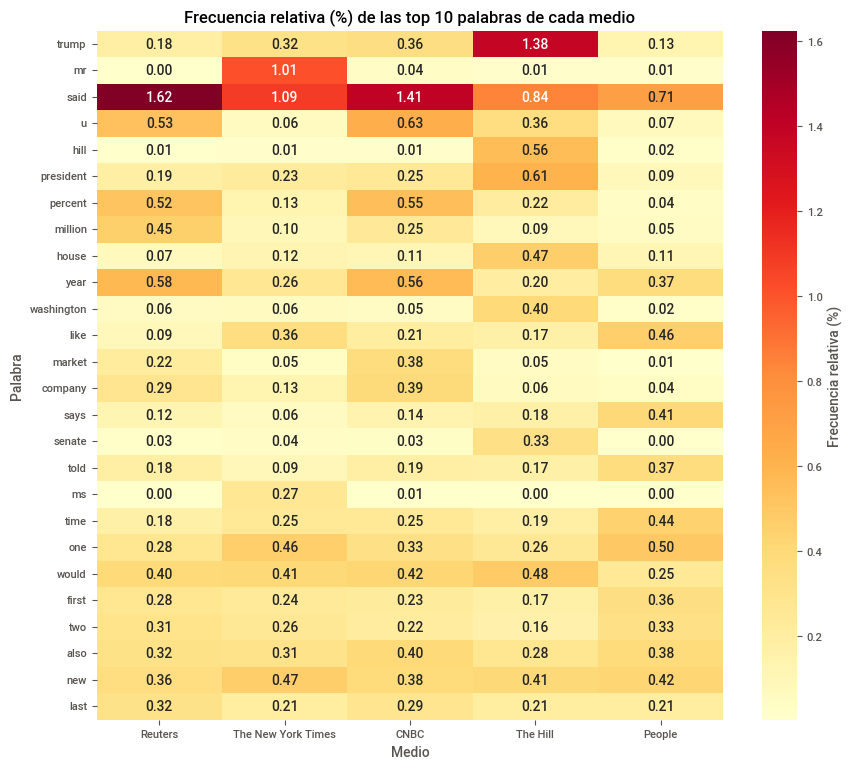

In [40]:
# 2.A (extra) — Heatmap: frecuencia relativa (%) de las palabras "top" en cada medio.
# Se construye la unión de los top-N de cada medio y se muestra cómo se distribuyen
# entre los 5 medios. Sirve para ver palabras que destacan en un medio respecto del resto.

TOP_N_HEAT = 10

# Counters por medio (sobre Tokens ya filtrados)
all_counters = {}
for pub in top_5_publications:
    counter = Counter()
    for tokens in df_top_5.loc[df_top_5["publication"] == pub, "Tokens"]:
        counter.update(tokens)
    all_counters[pub] = (counter, sum(counter.values()) or 1)

distinct_words = set()
for pub, items in top_clean.items():
    for w, _ in items[:TOP_N_HEAT]:
        distinct_words.add(w)

heat_df = pd.DataFrame(
    {pub: {w: all_counters[pub][0].get(w, 0) / all_counters[pub][1] * 100
           for w in distinct_words}
     for pub in top_5_publications}
)

# Ordenar palabras por máxima diferencia entre medios (las más distintivas arriba)
heat_df = heat_df.loc[
    (heat_df.max(axis=1) - heat_df.min(axis=1))
    .sort_values(ascending=False).index
]

plt.figure(figsize=(9, max(6, len(heat_df) * 0.3)))
sns.heatmap(heat_df, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "Frecuencia relativa (%)"})
plt.title(f"Frecuencia relativa (%) de las top {TOP_N_HEAT} palabras de cada medio")
plt.xlabel("Medio")
plt.ylabel("Palabra")
plt.tight_layout()
plt.show()


**Lectura de los resultados (versión filtrada).**

Una vez removidos *stopwords* y pistas del medio, los rankings dejan de ser intercambiables y empiezan a verse las diferencias temáticas y de estilo editorial entre medios: vocabulario financiero / de cable en Reuters y CNBC, vocabulario político en The Hill, vocabulario más narrativo en NYT, y vocabulario de entretenimiento / celebridades en People. El heatmap complementa los subplots: una palabra como *trump* o *house* pesa muy distinto en The Hill que en People, y eso queda explícito al verlas en una misma escala.

---

### Ideas para modificar la visualización

**Por sección temática.** Restringir el conteo a artículos de una misma `section` (por ejemplo *politics* o *business*) y rehacer el top-N por medio dentro de esa sección. Lo que quedaría reflejado serían diferencias de **estilo editorial** dentro del mismo tema, no diferencias de cobertura. Limitación práctica (ya discutida en 1.F): *The Hill* no tiene `section` y *People* casi solo cubre entretenimiento, por lo que la comparación quedaría sesgada o limitada a 3 medios.

**Por fecha.** Dos caminos:
1. Graficar la **serie de tiempo** de la frecuencia (por mes o trimestre) de un conjunto de palabras-clave (*trump, biden, covid, market, election...*) discriminado por medio. Permitiría ver cómo cada medio reacciona ante un mismo evento.
2. Comparar el **top-N de un año contra el de otro** dentro del mismo medio (p. ej. 2017 vs 2019) para detectar cambios de agenda editorial.

**Por tipo de noticia.** Usar la `section` como proxy de tipo (*opinion / business / politics / sports...*) y rehacer la visualización agrupando por tipo en lugar de por medio: respondería *qué palabras caracterizan a una nota de opinión vs una de cable*, transversal a los medios. Alternativa: clusterizar artículos por características estructurales (largo, presencia de firmas, presencia de citas) y comparar top-N por cluster.


## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

Total de palabras por medio:
publication
Reuters               2512074
The New York Times    2597094
CNBC                  1212264
The Hill              1345385
People                 634673

Promedio de palabras por articulo:
publication
Reuters               266
The New York Times    914
CNBC                  462
The Hill              573
People                415

Promedio de palabras UNICAS por articulo (proxy de riqueza lexica):
publication
Reuters               145
The New York Times    403
CNBC                  228
The Hill              293
People                214


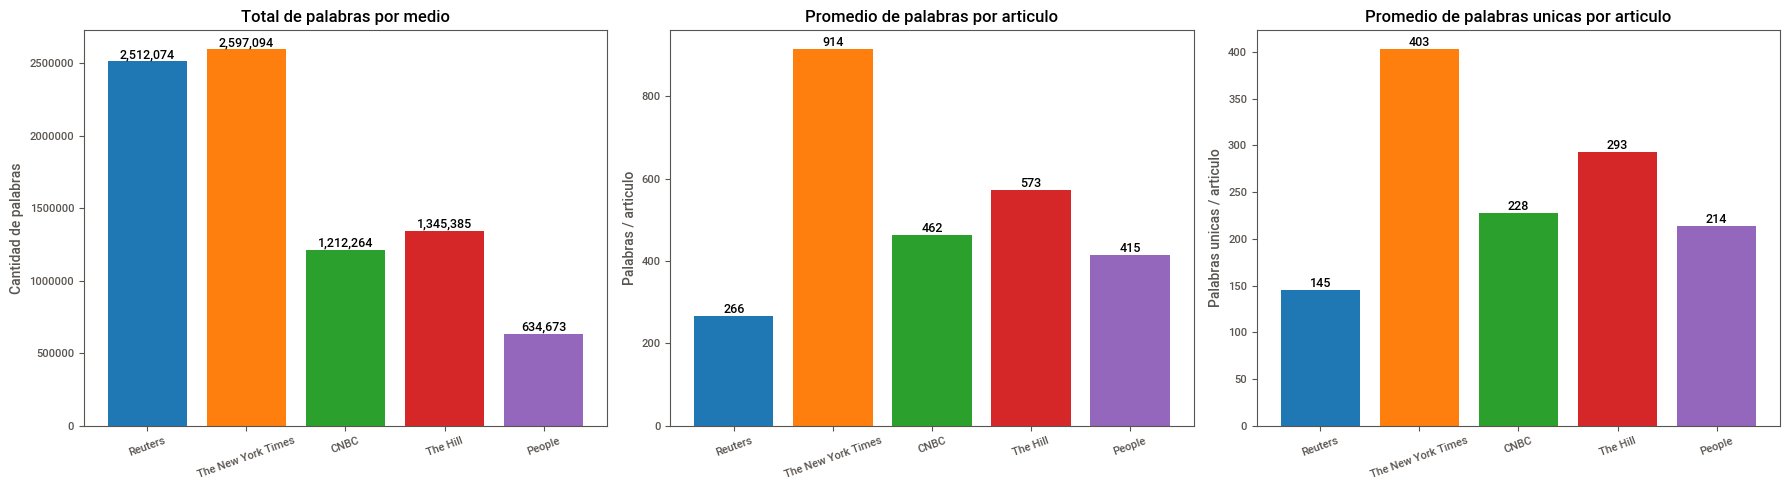

In [41]:
# 2.B — Cantidad de palabras por medio.
# Para esta parte usamos directamente CleanText (no Tokens), porque la pregunta es
# sobre cuantas palabras hay en los articulos de cada medio, no sobre las palabras
# significativas. Se cuentan palabras separadas por espacios.

words_per_article = df_top_5["CleanText"].fillna("").str.split().apply(len)
df_top_5["NumWords"] = words_per_article

# Cantidad de palabras UNICAS por articulo (vocabulario distinto del articulo).
# Sirve como proxy simple de "riqueza lexica": cuanto vocabulario distinto usa
# en promedio una nota de cada medio.
df_top_5["NumUniqueWords"] = (
    df_top_5["CleanText"].fillna("").str.split().apply(lambda ws: len(set(ws)))
)

total_por_medio = (
    df_top_5.groupby("publication")["NumWords"]
    .sum()
    .reindex(top_5_publications)
)

promedio_por_medio = (
    df_top_5.groupby("publication")["NumWords"]
    .mean()
    .reindex(top_5_publications)
    .round(0)
    .astype(int)
)

unicas_por_medio = (
    df_top_5.groupby("publication")["NumUniqueWords"]
    .mean()
    .reindex(top_5_publications)
    .round(0)
    .astype(int)
)

print("Total de palabras por medio:")
print(total_por_medio.to_string())
print()
print("Promedio de palabras por articulo:")
print(promedio_por_medio.to_string())
print()
print("Promedio de palabras UNICAS por articulo (proxy de riqueza lexica):")
print(unicas_por_medio.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette("tab10", n_colors=5)

axes[0].bar(total_por_medio.index, total_por_medio.values, color=palette)
axes[0].set_title("Total de palabras por medio")
axes[0].set_ylabel("Cantidad de palabras")
axes[0].tick_params(axis="x", rotation=20)
for x, v in zip(total_por_medio.index, total_por_medio.values):
    axes[0].text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

axes[1].bar(promedio_por_medio.index, promedio_por_medio.values, color=palette)
axes[1].set_title("Promedio de palabras por articulo")
axes[1].set_ylabel("Palabras / articulo")
axes[1].tick_params(axis="x", rotation=20)
for x, v in zip(promedio_por_medio.index, promedio_por_medio.values):
    axes[1].text(x, v, f"{v}", ha="center", va="bottom", fontsize=9)

axes[2].bar(unicas_por_medio.index, unicas_por_medio.values, color=palette)
axes[2].set_title("Promedio de palabras unicas por articulo")
axes[2].set_ylabel("Palabras unicas / articulo")
axes[2].tick_params(axis="x", rotation=20)
for x, v in zip(unicas_por_medio.index, unicas_por_medio.values):
    axes[2].text(x, v, f"{v}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


**Problema observado y forma de resolverlo.**

El grafico de la *izquierda* (total de palabras por medio) esta dominado por *Reuters*. Pero esto **no** significa que Reuters tenga articulos mas largos: significa que tiene **muchos mas articulos** que el resto (9.431 frente a ~1.500–2.800 de los demas, ver Tabla del top 5 en la Parte 1). El total de palabras mezcla dos cosas: cuantos articulos hay y cuan largo es cada uno.

La forma simple de resolverlo es mirar el **promedio de palabras por articulo** (grafico del medio): ahi se ve que en realidad *NYT* y *People* son los que escriben articulos mas largos, mientras que *Reuters* y *The Hill* son los que escriben articulos mas cortos (estilo cable / nota politica corta). Esa es la metrica correcta para comparar "extension de las notas" entre medios sin que el volumen editorial confunda la lectura.

Como complemento se incluye un tercer grafico con el **promedio de palabras unicas por articulo** (vocabulario distinto por nota). Aporta una nocion simple de **riqueza lexica**: dos medios pueden escribir notas del mismo largo y aun asi usar vocabulario muy distinto (uno mas repetitivo, otro mas variado). No lo pide la consigna, pero permite distinguir un medio que escribe largo repitiendo terminos tecnicos de otro que escribe largo cubriendo temas variados.


## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

Matriz de menciones (conteo total) - fila = medio que escribe, columna = medio mencionado:
                    Reuters  The New York Times  CNBC  The Hill  People
Reuters               11623                  39    45         0     107
The New York Times       51                1204    19         7      88
CNBC                   1199                  54  1708         4     121
The Hill                123                 180    20      3558      33
People                    7                  53     5         4    1555

Matriz normalizada (% de articulos del medio i que mencionan al menos una vez al medio j):
                    Reuters  The New York Times  CNBC  The Hill  People
Reuters                94.1                 0.3   0.3       0.0     0.9
The New York Times      1.5                22.0   0.5       0.2     2.2
CNBC                   31.8                 1.8  34.8       0.1     1.8
The Hill                3.0                 6.5   0.6      99.4     1.3
People                  0

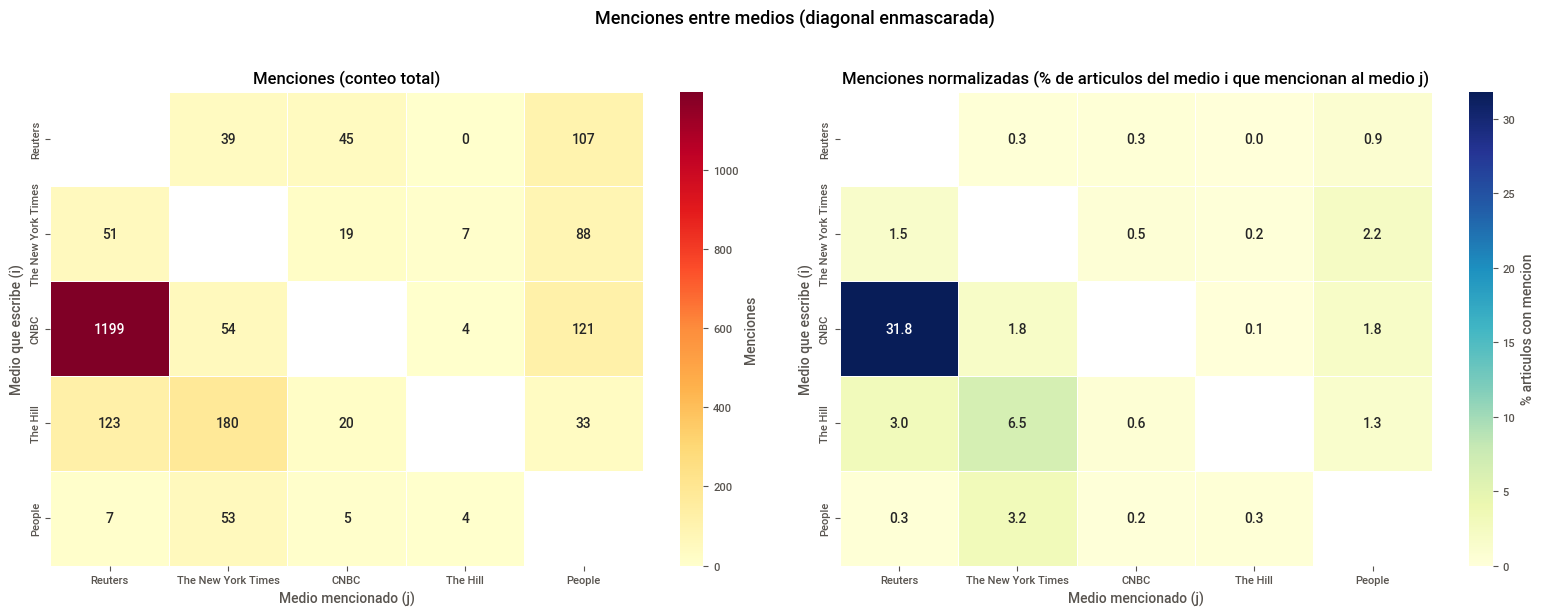

In [42]:
# 2.C — Matriz 5x5 de menciones entre medios.
# Para cada par (i, j), contamos cuantas veces los articulos del medio i mencionan
# al medio j. Se usa el campo "article" en su forma original (sin clean_text) para
# preservar mayusculas y poder distinguir el nombre propio "People" (la revista)
# de la palabra comun "people".

# Patrones por medio. Para "People" se buscan las formas estrictas (PEOPLE en
# mayusculas, "People magazine", people.com) Y "People" mid-sentence: usando un
# lookbehind se exige que el caracter anterior sea letra minuscula, coma, punto
# y coma o dos puntos seguido de espacio. Asi se evita contar "People" como
# inicio de oracion (donde podria ser la palabra comun) pero se cuenta cuando
# aparece en medio de una frase, que es mucho mas probable que refiera a la
# revista (p.ej. "told People that ...", "People reported that ...").
MEDIA_MENTION_PATTERNS = {
    "Reuters":            r"\b[Rr]euters\b",
    "The Hill":           r"\b(?:[Tt]he\s+Hill|TheHill)\b",
    "CNBC":               r"\bCNBC\b",
    "The New York Times": r"\b(?:[Tt]he\s+New\s+York\s+Times|NYT|nytimes)\b",
    "People":             r"(?:\bPEOPLE\b|People magazine|people\.com|(?<=[a-z,;:]\s)People\b)",
}

compiled = {pub: re.compile(p) for pub, p in MEDIA_MENTION_PATTERNS.items()}

# 1) Matriz de conteo: total de menciones (puede haber varias por articulo).
mentions_matrix = pd.DataFrame(
    0,
    index=top_5_publications,
    columns=top_5_publications,
    dtype=int,
)

# 2) Matriz normalizada: % de articulos del medio i que mencionan al menos
#    una vez al medio j. No depende del volumen total de articulos del medio i
#    y permite comparar a cuanta proporcion de la cobertura "le toca" cada otro
#    medio como referencia.
mentions_pct = pd.DataFrame(
    0.0,
    index=top_5_publications,
    columns=top_5_publications,
    dtype=float,
)

for medio_i in top_5_publications:
    textos = df_top_5.loc[df_top_5["publication"] == medio_i, "article"].dropna()
    total_articulos = len(textos)
    for medio_j, regex in compiled.items():
        # Total de matches (cuenta menciones, incluso varias por articulo).
        mentions_matrix.loc[medio_i, medio_j] = sum(len(regex.findall(t)) for t in textos)
        # Articulos con al menos una mencion al medio j.
        with_mention = sum(1 for t in textos if regex.search(t))
        mentions_pct.loc[medio_i, medio_j] = (
            with_mention / total_articulos * 100 if total_articulos else 0.0
        )

print("Matriz de menciones (conteo total) - fila = medio que escribe, columna = medio mencionado:")
print(mentions_matrix)
print()
print("Matriz normalizada (% de articulos del medio i que mencionan al menos una vez al medio j):")
print(mentions_pct.round(1))

mask = np.eye(len(top_5_publications), dtype=bool)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    mentions_matrix,
    mask=mask,
    annot=True, fmt="d", cmap="YlOrRd",
    cbar_kws={"label": "Menciones"},
    linewidths=0.5, linecolor="white",
    ax=axes[0],
)
axes[0].set_title("Menciones (conteo total)")
axes[0].set_xlabel("Medio mencionado (j)")
axes[0].set_ylabel("Medio que escribe (i)")

sns.heatmap(
    mentions_pct,
    mask=mask,
    annot=True, fmt=".1f", cmap="YlGnBu",
    cbar_kws={"label": "% articulos con mencion"},
    linewidths=0.5, linecolor="white",
    ax=axes[1],
)
axes[1].set_title("Menciones normalizadas (% de articulos del medio i que mencionan al medio j)")
axes[1].set_xlabel("Medio mencionado (j)")
axes[1].set_ylabel("Medio que escribe (i)")

plt.suptitle("Menciones entre medios (diagonal enmascarada)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

**Pregunta 1 — Largo de los articulos.**
¿Cómo se distribuye el largo de los articulos dentro de cada medio? ¿Hay medios con largos muy homogeneos y otros con mucha varianza?
*Camino sin implementar:* a partir de la columna `NumWords` calculada en 2.B, mirar las distribuciones por medio (estadisticos descriptivos como mediana y desvio, y un boxplot por medio para ver dispersion y outliers). Esto separa "medio que escribe siempre lo mismo de largo" de "medio que mezcla notas cortas con largas".

**Pregunta 2 — Reciprocidad de las menciones.**
¿Las menciones entre medios son reciprocas? Por ejemplo, si *CNBC* cita mucho a *Reuters*, ¿*Reuters* tambien cita a *CNBC* con frecuencia similar?
*Camino sin implementar:* comparar la matriz `mentions_matrix` con su traspuesta. Si la entrada (i, j) es muy distinta de (j, i), hay una asimetria: el medio i depende de j como fuente pero no al reves. Inspeccionar visualmente cuales pares son simetricos y cuales no.

**Pregunta 3 — Vocabulario distintivo por medio.**
Mas alla de las pistas obvias detectadas en 1.E (nombres del propio medio, firmas), ¿cada medio tiene un vocabulario propio que lo diferencia del resto?
*Camino sin implementar:* aprovechando los `Tokens` ya filtrados de 2.A, para cada palabra calcular su frecuencia relativa en cada medio y quedarse con las que aparecen mucho en un medio y poco en los otros (alta diferencia entre maximo y minimo entre medios). El heatmap de 2.A ya hace una version inicial de esto sobre el top-N de cada medio; se podria extender a todo el vocabulario para detectar palabras distintivas mas alla del top.
